# Modèle ColBERT

On s'intéresse ici au modèle ColBERT, qui propose ...

In [ ]:
# !uv pip install --upgrade python-terrier
# !uv pip install --upgrade git+https://github.com/terrierteam/pyterrier_colbert


Resolved 43 packages in 235ms                                        
Prepared 5 packages in 3ms                                               
Uninstalled 5 packages in 157ms
Installed 5 packages in 86ms                                
 - ir-datasets==0.5.9
 + ir-datasets==0.5.11
 - numpy==1.26.4
 + numpy==2.4.4
 - packaging==23.2
 + packaging==26.2
 - pyarrow==12.0.1
 + pyarrow==24.0.0
 - pytz==2023.4
 + pytz==2026.2
Resolved 100 packages in 2.65s                                       
Prepared 5 packages in 1ms                                               
Uninstalled 5 packages in 174ms
Installed 5 packages in 40ms                                
 - ir-datasets==0.5.11
 + ir-datasets==0.5.9
 - numpy==2.4.4
 + numpy==1.26.4
 - packaging==26.2
 + packaging==23.2
 - pyarrow==24.0.0
 + pyarrow==12.0.1
 - pytz==2026.2
 + pytz==2023.4


In [1]:
#initialisation pyterrier
import pyterrier as pt
if not pt.started():
    pt.init()

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_28698/1038952076.py:3: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_28698/1038952076.py:4: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


In [ ]:
#récupération du dataset covid19
dataset = pt.datasets.get_dataset('irds:cord19/trec-covid')
topics = dataset.get_topics(variant='description')
qrels = dataset.get_qrels()

#construction de l'index
import os

cord19 = pt.datasets.get_dataset('irds:cord19/trec-covid')
pt_index_path = './terrier_cord19'

if not os.path.exists(pt_index_path + "/data.properties"):
    # create the index, using the IterDictIndexer indexer 
    indexer = pt.index.IterDictIndexer(pt_index_path)

    # we give the dataset get_corpus_iter() directly to the indexer
    # while specifying the fields to index and the metadata to record
    index_ref = indexer.index(cord19.get_corpus_iter(), 
                              fields=('abstract',), 
                            meta=('docno',)
                              )

else:
    # if you already have the index, use it.
    index_ref = pt.IndexRef.of(pt_index_path + "/data.properties")

index = pt.IndexFactory.of(index_ref)


import os

if not os.path.exists("terrier_index.zip"):
  !wget http://www.dcs.gla.ac.uk/~craigm/ecir2021-tutorial/terrier_index.zip
  !unzip -j terrier_index.zip -d terrier_index

index_ref = pt.IndexRef.of("./terrier_index/data.properties")
index = pt.IndexFactory.of(index_ref)

## chargement du modèle ColBERT

In [4]:
import pyterrier_colbert.ranking
colbert_factory = pyterrier_colbert.ranking.ColBERTFactory(
    "http://www.dcs.gla.ac.uk/~craigm/colbert.dnn.zip", None, None)
colbert = colbert_factory.text_scorer(doc_attr='abstract')

[INFO] PyTorch version 1.8.1+cu101 available.
[INFO] TensorFlow version 2.5.0 available.
/usr/local/lib/python3.7/dist-packages/pyterrier_colbert/ranking.py:221: UserWarning: No index_root and index_name specified - no index ranking possible
  warn("No index_root and index_name specified - no index ranking possible")
/usr/local/lib/python3.7/dist-packages/pyterrier_colbert/ranking.py:237: UserWarning: Faiss not installed. You cannot do retrieval
  warn("Faiss not installed. You cannot do retrieval")
[INFO] Lock 139884891868112 acquired on /root/.cache/torch/transformers/4dad0251492946e18ac39290fcfe91b89d370fee250efe9521476438fe8ca185.7156163d5fdc189c3016baca0775ffce230789d7fa2a42ef516483e4ca884517.lock
[INFO] https://s3.amazonaws.com/models.huggingface.co/bert/bert-base-uncased-config.json not found in cache or force_download set to True, downloading to /root/.cache/torch/transformers/tmpcmarjxis


[INFO] storing https://s3.amazonaws.com/models.huggingface.co/bert/bert-base-uncased-config.json in cache at /root/.cache/torch/transformers/4dad0251492946e18ac39290fcfe91b89d370fee250efe9521476438fe8ca185.7156163d5fdc189c3016baca0775ffce230789d7fa2a42ef516483e4ca884517
[INFO] creating metadata file for /root/.cache/torch/transformers/4dad0251492946e18ac39290fcfe91b89d370fee250efe9521476438fe8ca185.7156163d5fdc189c3016baca0775ffce230789d7fa2a42ef516483e4ca884517
[INFO] Lock 139884891868112 released on /root/.cache/torch/transformers/4dad0251492946e18ac39290fcfe91b89d370fee250efe9521476438fe8ca185.7156163d5fdc189c3016baca0775ffce230789d7fa2a42ef516483e4ca884517.lock
[INFO] loading configuration file https://s3.amazonaws.com/models.huggingface.co/bert/bert-base-uncased-config.json from cache at /root/.cache/torch/transformers/4dad0251492946e18ac39290fcfe91b89d370fee250efe9521476438fe8ca185.7156163d5fdc189c3016baca0775ffce230789d7fa2a42ef516483e4ca884517
[INFO] Model config BertConfig {
 

[INFO] storing https://cdn.huggingface.co/bert-base-uncased-pytorch_model.bin in cache at /root/.cache/torch/transformers/f2ee78bdd635b758cc0a12352586868bef80e47401abe4c4fcc3832421e7338b.36ca03ab34a1a5d5fa7bc3d03d55c4fa650fed07220e2eeebc06ce58d0e9a157
[INFO] creating metadata file for /root/.cache/torch/transformers/f2ee78bdd635b758cc0a12352586868bef80e47401abe4c4fcc3832421e7338b.36ca03ab34a1a5d5fa7bc3d03d55c4fa650fed07220e2eeebc06ce58d0e9a157
[INFO] Lock 139884892014864 released on /root/.cache/torch/transformers/f2ee78bdd635b758cc0a12352586868bef80e47401abe4c4fcc3832421e7338b.36ca03ab34a1a5d5fa7bc3d03d55c4fa650fed07220e2eeebc06ce58d0e9a157.lock
[INFO] loading weights file https://cdn.huggingface.co/bert-base-uncased-pytorch_model.bin from cache at /root/.cache/torch/transformers/f2ee78bdd635b758cc0a12352586868bef80e47401abe4c4fcc3832421e7338b.36ca03ab34a1a5d5fa7bc3d03d55c4fa650fed07220e2eeebc06ce58d0e9a157
[WARNING] Some weights of the model checkpoint at bert-base-uncased were not u

[Jun 17, 13:21:42] #> Loading model checkpoint.
[Jun 17, 13:21:42] #> Loading checkpoint http://www.dcs.gla.ac.uk/~craigm/colbert.dnn.zip


Downloading: "http://www.dcs.gla.ac.uk/~craigm/colbert.dnn.zip" to /root/.cache/torch/hub/checkpoints/colbert.dnn.zip


/usr/local/lib/python3.7/dist-packages/torch/hub.py:452: UserWarning: Falling back to the old format < 1.6. This support will be deprecated in favor of default zipfile format introduced in 1.6. Please redo torch.save() to save it in the new zipfile format.
  warnings.warn('Falling back to the old format < 1.6. This support will be '


[Jun 17, 13:22:53] #> checkpoint['epoch'] = 0
[Jun 17, 13:22:53] #> checkpoint['batch'] = 44500


[INFO] Lock 139884891168464 acquired on /root/.cache/torch/transformers/26bc1ad6c0ac742e9b52263248f6d0f00068293b33709fae12320c0e35ccfbbb.542ce4285a40d23a559526243235df47c5f75c197f04f37d1a0c124c32c9a084.lock
[INFO] https://s3.amazonaws.com/models.huggingface.co/bert/bert-base-uncased-vocab.txt not found in cache or force_download set to True, downloading to /root/.cache/torch/transformers/tmppnh1o9hy


[INFO] storing https://s3.amazonaws.com/models.huggingface.co/bert/bert-base-uncased-vocab.txt in cache at /root/.cache/torch/transformers/26bc1ad6c0ac742e9b52263248f6d0f00068293b33709fae12320c0e35ccfbbb.542ce4285a40d23a559526243235df47c5f75c197f04f37d1a0c124c32c9a084
[INFO] creating metadata file for /root/.cache/torch/transformers/26bc1ad6c0ac742e9b52263248f6d0f00068293b33709fae12320c0e35ccfbbb.542ce4285a40d23a559526243235df47c5f75c197f04f37d1a0c124c32c9a084
[INFO] Lock 139884891168464 released on /root/.cache/torch/transformers/26bc1ad6c0ac742e9b52263248f6d0f00068293b33709fae12320c0e35ccfbbb.542ce4285a40d23a559526243235df47c5f75c197f04f37d1a0c124c32c9a084.lock
[INFO] loading file https://s3.amazonaws.com/models.huggingface.co/bert/bert-base-uncased-vocab.txt from cache at /root/.cache/torch/transformers/26bc1ad6c0ac742e9b52263248f6d0f00068293b33709fae12320c0e35ccfbbb.542ce4285a40d23a559526243235df47c5f75c197f04f37d1a0c124c32c9a084
[INFO] loading file https://s3.amazonaws.com/models.

Exécution des requêtes du dataset et calcul des métriques

In [5]:
br = pt.BatchRetrieve(index) % 100
pipeline = br >> pt.text.get_text(dataset, 'abstract') >> colbert
pt.Experiment(
    [br, pipeline],
    topics,
    qrels,
    names=['DPH', 'DPH >> ColBERT'],
    eval_metrics=["map", "ndcg", 'ndcg_cut.10', 'P.10', 'mrt']
)

[INFO] NumExpr defaulting to 2 threads.


,name,map,ndcg,ndcg_cut.10,P.10,mrt
0,DPH,0.068006,0.165607,0.609058,0.658,70.608992
1,DPH >> ColBERT,0.074670,0.172034,0.690447,0.752,530.858721


on souhaite ici visualiser les résultats du modèle, et surtout visualiser l'attention calculée sur le texte.

In [6]:
res = pipeline(topics.iloc[:1])
res.merge(dataset.get_qrels(), how='left').head()

,qid,query,docno,score,rank,label,iteration
0,1,what is the origin of covid 19,4dtk1kyh,24.866121,0,2.0,3
1,1,what is the origin of covid 19,jwxt4ygt,23.811007,1,2.0,3.5
2,1,what is the origin of covid 19,bn7hsuv9,23.811007,2,2.0,3.5
3,1,what is the origin of covid 19,6ck2ntid,23.699537,3,NaN,NaN
4,1,what is the origin of covid 19,8a6flxl6,23.699537,4,NaN,NaN


le premier document est pertinent pour la requête q0. Nous observons ci-dessous la carte d'attention associée au calcul du score : 

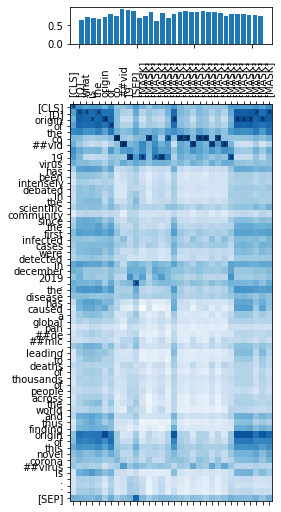

In [7]:
text = dataset.irds_ref().docs_store().get('4dtk1kyh').abstract[:300] + '...' # truncate text
colbert_factory.explain_text('what is the origin of covid 19', text)